In [1]:
!unzip -q Mlproject.zip


In [4]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, random_split


transform = transforms.Compose([
    transforms.Resize((128, 128)), # Crush them to identical squares
    transforms.ToTensor()          # Convert pixels to mathematical tensors
])


full_dataset = torchvision.datasets.ImageFolder(root='Mlproject-Copy', transform=transform) #to convert pixels to mathematical format


train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Set a manual seed so our random split is the same every time we run it
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)

print(f"Total images found: {len(full_dataset)}")
print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Categories (Classes) found: {full_dataset.classes}")

Total images found: 90
Training images: 72
Validation images: 18
Categories (Classes) found: ['book_a', 'book_b', 'book_c']


In [5]:
import torch.nn as nn
import torch.nn.functional as F

class StorybookCNN(nn.Module):
    def __init__(self):
        super(StorybookCNN, self).__init__()

        # 1.Convolutional Layers
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)

        # 2. Shrinking Layer (Pooling)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # 3. Regularization (Dropout) - Set to 25% for our baseline experiment
        self.dropout = nn.Dropout(0.25)

        # 4. Decision Makers (Linear Layers)
        # Because we shrink the 128x128 image by half twice (pooling),
        # it becomes 32x32. We have 32 output channels from conv2.
        # 32 * 32 * 32 = 32768
        self.fc1 = nn.Linear(32768, 128)
        self.fc2 = nn.Linear(128, 3) # 3 final outputs for your 3 specific books

    def forward(self, x):
        # Conv1 -> ReLU (activation) -> Pool
        x = self.pool(F.relu(self.conv1(x)))
        # Conv2 -> ReLU -> Pool
        x = self.pool(F.relu(self.conv2(x)))

        # Flatten the 2D grids into a 1D line for the final decision layers
        x = x.view(-1, 32768)

        # Apply Dropout, pass through hidden layer, then final output
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

#Building an architecture to see if it worked correctly
model = StorybookCNN()
print("Model architecture built successfully!")
print(model)

Model architecture built successfully!
StorybookCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=32768, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)


In [6]:
import torch.optim as optim

#1. Hyperparameters
BATCH_SIZE = 16      # Number of images processed at once
LEARNING_RATE = 0.001 # How fast the model updates its weights
EPOCHS = 15          # How many times we loop through the whole dataset

# 2. DataLoaders
# This wraps your dataset into an iterable object that feeds batches automatically
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 3. Loss and Optimizer
criterion = nn.CrossEntropyLoss() # The standard loss function for classification
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Lists to save our data so we can plot it
train_losses = []
val_accuracies = []

print("Starting Training...")

#4. The Training Loop
for epoch in range(EPOCHS):
    model.train() # Tell the model to start training (Turns ON Dropout)
    running_loss = 0.0

    for images, labels in train_loader:
        # Step A: Clear out old mathematical gradients
        optimizer.zero_grad()

        # Step B: Forward Pass (Make a guess)
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Step C: Backpropagation - figure out which weights to change
        loss.backward()

        # Step D: Optimize: apply the changes to the weights)
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    #5. The Validation Phase
    model.eval() # Turns OFF Dropout
    correct = 0
    total = 0

    with torch.no_grad(): # Don't track math for updating weights (saves memory)
        for images, labels in val_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = 100 * correct / total
    val_accuracies.append(val_accuracy)

    print(f"Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {avg_train_loss:.4f} - Validation Accuracy: {val_accuracy:.2f}%")

print("Training Complete!")

Starting Training...
Epoch [1/15] - Train Loss: 1.3026 - Validation Accuracy: 50.00%
Epoch [2/15] - Train Loss: 1.1287 - Validation Accuracy: 50.00%
Epoch [3/15] - Train Loss: 1.0977 - Validation Accuracy: 27.78%
Epoch [4/15] - Train Loss: 1.0624 - Validation Accuracy: 33.33%
Epoch [5/15] - Train Loss: 0.9975 - Validation Accuracy: 33.33%
Epoch [6/15] - Train Loss: 0.9119 - Validation Accuracy: 22.22%
Epoch [7/15] - Train Loss: 0.8960 - Validation Accuracy: 33.33%
Epoch [8/15] - Train Loss: 0.8238 - Validation Accuracy: 38.89%
Epoch [9/15] - Train Loss: 0.6933 - Validation Accuracy: 27.78%
Epoch [10/15] - Train Loss: 0.6425 - Validation Accuracy: 38.89%
Epoch [11/15] - Train Loss: 0.5389 - Validation Accuracy: 33.33%
Epoch [12/15] - Train Loss: 0.5259 - Validation Accuracy: 44.44%
Epoch [13/15] - Train Loss: 0.4468 - Validation Accuracy: 44.44%
Epoch [14/15] - Train Loss: 0.3603 - Validation Accuracy: 44.44%
Epoch [15/15] - Train Loss: 0.2913 - Validation Accuracy: 33.33%
Training Comp

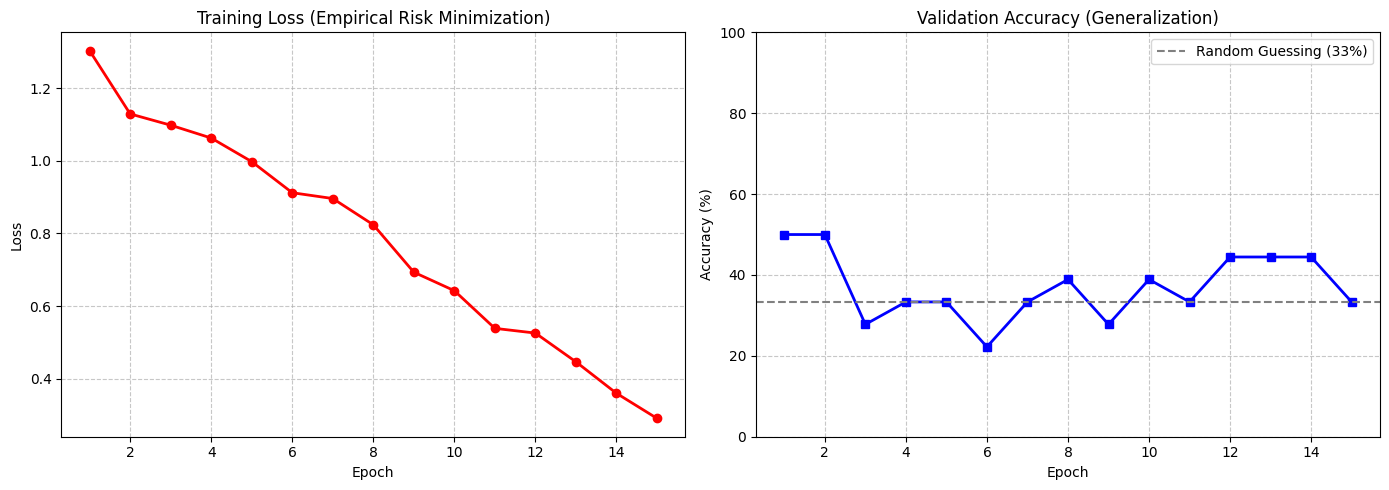

In [7]:
import matplotlib.pyplot as plt

# Create a wide figure to hold two side-by-side graphs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: Training Loss
ax1.plot(range(1, EPOCHS+1), train_losses, marker='o', color='red', linewidth=2)
ax1.set_title('Training Loss (Empirical Risk Minimization)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, linestyle='--', alpha=0.7)

# Graph 2: Validation Accuracy
ax2.plot(range(1, EPOCHS+1), val_accuracies, marker='s', color='blue', linewidth=2)
ax2.set_title('Validation Accuracy (Generalization)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim(0, 100)
ax2.axhline(y=33.33, color='gray', linestyle='--', label='Random Guessing (33%)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Starting Experiment 1: High Dropout & Regularization...
Epoch [1/15] - Train Loss: 1.1333 - Val Accuracy: 22.22%
Epoch [2/15] - Train Loss: 1.1231 - Val Accuracy: 44.44%
Epoch [3/15] - Train Loss: 1.0550 - Val Accuracy: 27.78%
Epoch [4/15] - Train Loss: 0.9755 - Val Accuracy: 27.78%
Epoch [5/15] - Train Loss: 0.8918 - Val Accuracy: 27.78%
Epoch [6/15] - Train Loss: 0.8077 - Val Accuracy: 38.89%
Epoch [7/15] - Train Loss: 0.7482 - Val Accuracy: 44.44%
Epoch [8/15] - Train Loss: 0.7260 - Val Accuracy: 38.89%
Epoch [9/15] - Train Loss: 0.5430 - Val Accuracy: 33.33%
Epoch [10/15] - Train Loss: 0.4937 - Val Accuracy: 38.89%
Epoch [11/15] - Train Loss: 0.3742 - Val Accuracy: 33.33%
Epoch [12/15] - Train Loss: 0.3068 - Val Accuracy: 38.89%
Epoch [13/15] - Train Loss: 0.2514 - Val Accuracy: 44.44%
Epoch [14/15] - Train Loss: 0.1685 - Val Accuracy: 44.44%
Epoch [15/15] - Train Loss: 0.1249 - Val Accuracy: 50.00%


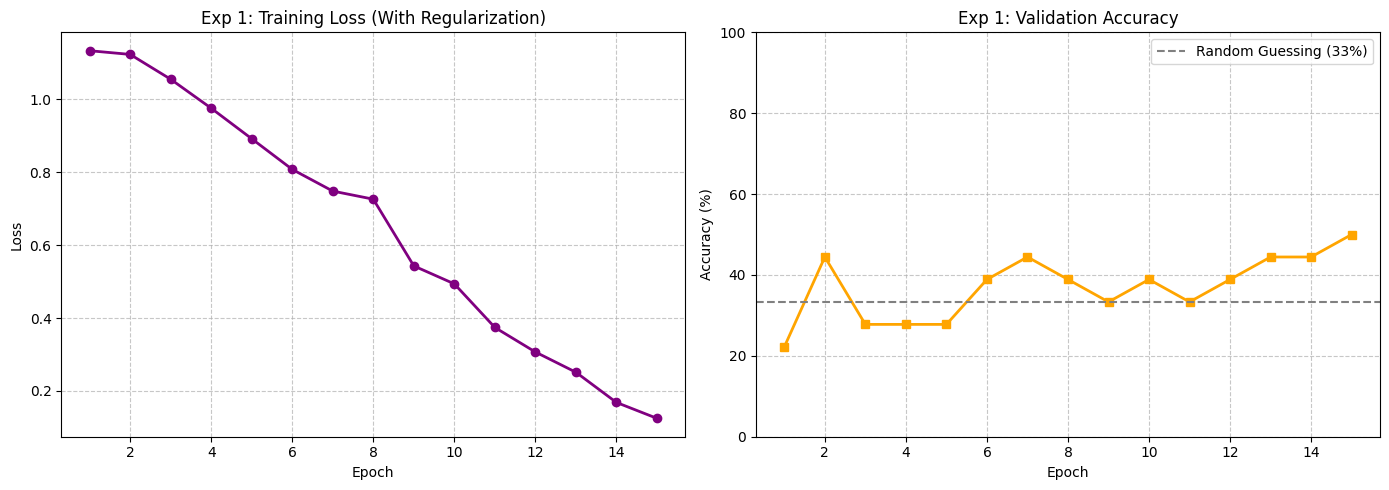

In [8]:
# EXP 1: High Dropout and Regularization

# 1. Redefine the model with 50% Dropout
class RegularizedCNN(nn.Module):
    def __init__(self):
        super(RegularizedCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # INCREASED DROPOUT HERE
        self.dropout = nn.Dropout(0.50)

        self.fc1 = nn.Linear(32768, 128)
        self.fc2 = nn.Linear(128, 3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32768)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

exp1_model = RegularizedCNN()

# 2. Add L2 Regularization (weight_decay) to the Optimizer
exp1_criterion = nn.CrossEntropyLoss()
exp1_optimizer = optim.Adam(exp1_model.parameters(), lr=0.001, weight_decay=1e-3)

exp1_train_losses = []
exp1_val_accuracies = []

print("Starting Experiment 1: High Dropout & Regularization...")

# 3. Training Loop
for epoch in range(EPOCHS):
    exp1_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        exp1_optimizer.zero_grad()
        outputs = exp1_model(images)
        loss = exp1_criterion(outputs, labels)
        loss.backward()
        exp1_optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    exp1_train_losses.append(avg_loss)

    exp1_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = exp1_model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    exp1_val_accuracies.append(val_acc)
    print(f"Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {avg_loss:.4f} - Val Accuracy: {val_acc:.2f}%")

# 4. Plotting the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(range(1, EPOCHS+1), exp1_train_losses, marker='o', color='purple', linewidth=2)
ax1.set_title('Exp 1: Training Loss (With Regularization)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.plot(range(1, EPOCHS+1), exp1_val_accuracies, marker='s', color='orange', linewidth=2)
ax2.set_title('Exp 1: Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim(0, 100)
ax2.axhline(y=33.33, color='gray', linestyle='--', label='Random Guessing (33%)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

WE ARE GONNA INTENTIONALLY CHANGE THE LEARNING RATE HERE AND MAKE IT MASSIVE TO SEE HOW IT EFFECTS THE OUTCOME
we are building a fresh new baseline model

Starting Experiment 2: Unstable Learning Rate (0.05)...
Epoch [1/15] - Train Loss: 788.4134 - Val Accuracy: 22.22%
Epoch [2/15] - Train Loss: 1.0929 - Val Accuracy: 22.22%
Epoch [3/15] - Train Loss: 1.1188 - Val Accuracy: 22.22%
Epoch [4/15] - Train Loss: 1.1022 - Val Accuracy: 22.22%
Epoch [5/15] - Train Loss: 1.0927 - Val Accuracy: 27.78%
Epoch [6/15] - Train Loss: 1.0976 - Val Accuracy: 27.78%
Epoch [7/15] - Train Loss: 1.1005 - Val Accuracy: 27.78%
Epoch [8/15] - Train Loss: 1.0979 - Val Accuracy: 27.78%
Epoch [9/15] - Train Loss: 1.0976 - Val Accuracy: 22.22%
Epoch [10/15] - Train Loss: 1.0969 - Val Accuracy: 22.22%
Epoch [11/15] - Train Loss: 1.0926 - Val Accuracy: 22.22%
Epoch [12/15] - Train Loss: 1.0937 - Val Accuracy: 22.22%
Epoch [13/15] - Train Loss: 1.0992 - Val Accuracy: 22.22%
Epoch [14/15] - Train Loss: 1.0938 - Val Accuracy: 22.22%
Epoch [15/15] - Train Loss: 1.0908 - Val Accuracy: 22.22%


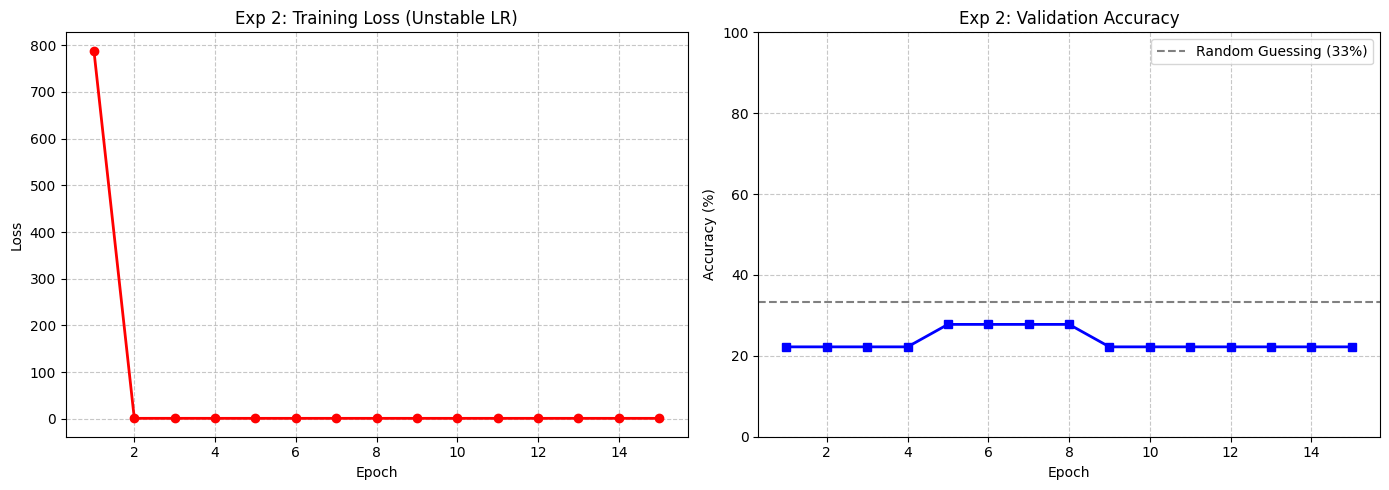

In [9]:
# EXP 2: Unstable Learning Rate

# 1. Build a fresh baseline model
exp2_model = StorybookCNN()

# 2. Massive Learning Rate
UNSTABLE_LR = 0.05
exp2_criterion = nn.CrossEntropyLoss()
exp2_optimizer = optim.Adam(exp2_model.parameters(), lr=UNSTABLE_LR)

exp2_train_losses = []
exp2_val_accuracies = []

print(f"Starting Experiment 2: Unstable Learning Rate ({UNSTABLE_LR})...")

for epoch in range(EPOCHS):
    exp2_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        exp2_optimizer.zero_grad()
        outputs = exp2_model(images)
        loss = exp2_criterion(outputs, labels)
        loss.backward()
        exp2_optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    exp2_train_losses.append(avg_loss)

    exp2_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = exp2_model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    exp2_val_accuracies.append(val_acc)
    print(f"Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {avg_loss:.4f} - Val Accuracy: {val_acc:.2f}%")

# 3. Plotting the chaos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(range(1, EPOCHS+1), exp2_train_losses, marker='o', color='red', linewidth=2)
ax1.set_title('Exp 2: Training Loss (Unstable LR)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.plot(range(1, EPOCHS+1), exp2_val_accuracies, marker='s', color='blue', linewidth=2)
ax2.set_title('Exp 2: Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim(0, 100)
ax2.axhline(y=33.33, color='gray', linestyle='--', label='Random Guessing (33%)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()